In [1]:
import torch
from torchvision import datasets, transforms

def get_device():
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
    return device



def get_mnist(batch_size, train):
    transform = transforms.Compose([transforms.ToTensor()])
    dataset = datasets.MNIST("data", 
                            train= train,
                            download=True,
                            transform = transform)
    dataset_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    return dataset_loader


In [2]:
train_dataset = get_mnist(batch_size=64, train=True)

In [3]:
import torch.nn as nn

class ConvAutoencoder(nn.Module):
    def __init__(self, hidden_channels, latent_dim, kernel_size, stride, padding):
        super().__init__()
        self.kwargs = {
            "hidden_channels": hidden_channels,
            "latent_dim": latent_dim,
            "kernel_size": kernel_size,
            "stride": stride,
            "padding": padding,
        }
        self.conv_encoder = nn.Sequential(
            nn.Conv2d(1, hidden_channels, kernel_size=kernel_size, stride=stride, padding=padding),
            nn.ReLU(),
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=kernel_size, stride=stride, padding=padding),
            nn.ReLU(),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 28, 28)
            after_conv1 = self.conv_encoder[:2](dummy)
            after_conv2 = self.conv_encoder(dummy)
            h1 = after_conv1.shape[2]
            h2 = after_conv2.shape[2]
            self.conv_out_shape = after_conv2.shape[1:]
            self.flat_size = after_conv2.flatten(1).shape[1]

        # output_padding resolves the ambiguity in ConvTranspose2d:
        # target = (input - 1) * stride - 2 * padding + kernel_size + output_padding
        self.op1 = h1 - ((h2 - 1) * stride - 2 * padding + kernel_size)
        self.op2 = 28 - ((h1 - 1) * stride - 2 * padding + kernel_size)

        self.encoder = nn.Sequential(
            self.conv_encoder,
            nn.Flatten(),
            nn.Linear(self.flat_size, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, self.flat_size),
            nn.ReLU(),
            nn.Unflatten(1, self.conv_out_shape),
            nn.ConvTranspose2d(hidden_channels, hidden_channels, kernel_size=kernel_size, stride=stride, padding=padding, output_padding=self.op1),
            nn.ReLU(),
            nn.ConvTranspose2d(hidden_channels, 1, kernel_size=kernel_size, stride=stride, padding=padding, output_padding=self.op2),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


class ConvAutoencoderClassifier(ConvAutoencoder):
    def __init__(self, hidden_channels, latent_dim, kernel_size, stride, padding):
        super().__init__(hidden_channels, latent_dim, kernel_size, stride, padding)
        self.classifier = nn.Linear(latent_dim, 10)

    def forward(self, x):
        z = self.encoder(x)
        return self.classifier(z)


class ConvAutoencoderClassifierTrained(nn.Module):
    """Frozen pretrained autoencoder with a newly trained classifier head."""
    def __init__(self, trained_model: ConvAutoencoder):
        super().__init__()
        self.trained_model = trained_model
        self.kwargs = trained_model.kwargs
        self.classifier = nn.Linear(trained_model.kwargs["latent_dim"], 10)

    def forward(self, x):
        with torch.no_grad():
            z = self.trained_model.encoder(x)
        return self.classifier(z)


class ConvAutoencoderDecoderTrained(nn.Module):
    """Frozen pretrained encoder+classifier with a newly trained decoder head."""
    def __init__(self, trained_model: ConvAutoencoderClassifier):
        super().__init__()
        self.trained_model = trained_model
        self.kwargs = trained_model.kwargs
        self.decoder = nn.Sequential(
            nn.Linear(10, trained_model.flat_size),
            nn.ReLU(),
            nn.Unflatten(1, trained_model.conv_out_shape),
            nn.ConvTranspose2d(trained_model.kwargs["hidden_channels"], trained_model.kwargs["hidden_channels"], kernel_size=trained_model.kwargs["kernel_size"], stride=trained_model.kwargs["stride"], padding=trained_model.kwargs["padding"], output_padding=trained_model.op1),
            nn.ReLU(),
            nn.ConvTranspose2d(trained_model.kwargs["hidden_channels"], 1, kernel_size=trained_model.kwargs["kernel_size"], stride=trained_model.kwargs["stride"], padding=trained_model.kwargs["padding"], output_padding=trained_model.op2),
            nn.Sigmoid(),
        )

    def forward(self, x):
        with torch.no_grad():
            z = self.trained_model.forward(x)
        return self.decoder(z)


In [4]:
from itertools import product

CHANNELS = [3, 15]
LATENT_DIMS = [4, 16, 32]
KS, ST, PAD = 3, 1, 1

def make_configs():
    return list(product(CHANNELS, LATENT_DIMS))

autoencoder_models = [
    ConvAutoencoder(c, ld, KS, ST, PAD) for c, ld in make_configs()
]
encoder_classifier_models = [
    ConvAutoencoderClassifier(c, ld, KS, ST, PAD) for c, ld in make_configs()
]
# Types 3 and 4 are instantiated after training types 1 and 2

print(f"Autoencoder models: {len(autoencoder_models)}")
print(f"Encoder+Classifier models: {len(encoder_classifier_models)}")


Autoencoder models: 6
Encoder+Classifier models: 6


In [5]:
import numpy as np

def train_reconstruction(model, loader, num_epochs=10, lr=1e-3):
    device = get_device()
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.L1Loss()
    model.losses = []
    print(f"Training reconstruction  config={model.kwargs}")
    for epoch in range(num_epochs):
        model.train()
        batch_losses = []
        for images, _ in loader:
            images = images.to(device)
            reconstructed = model(images)
            loss = criterion(reconstructed, images)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        median_loss = np.median(batch_losses)
        model.losses.append(median_loss)
        print(f"  Epoch [{epoch+1}/{num_epochs}]  L1={median_loss:.4f}")
    return model


def train_classification(model, loader, num_epochs=10, lr=1e-3):
    device = get_device()
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.losses = []
    print(f"Training classifier  config={model.kwargs}")
    for epoch in range(num_epochs):
        model.train()
        batch_losses = []
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        median_loss = np.median(batch_losses)
        model.losses.append(median_loss)
        print(f"  Epoch [{epoch+1}/{num_epochs}]  CE={median_loss:.4f}")
    return model


def get_balanced_subset(n_per_class=10, batch_size=64):
    from torch.utils.data import TensorDataset, DataLoader
    full = datasets.MNIST("data", train=True, download=True,
                          transform=transforms.Compose([transforms.ToTensor()]))
    found_images, found_labels = {d: [] for d in range(10)}, {d: [] for d in range(10)}
    for img, label in full:
        d = label if isinstance(label, int) else label.item()
        if len(found_images[d]) < n_per_class:
            found_images[d].append(img)
            found_labels[d].append(d)
        if all(len(v) == n_per_class for v in found_images.values()):
            break
    images = torch.cat([torch.stack(found_images[d]) for d in range(10)])
    labels = torch.tensor([l for d in range(10) for l in found_labels[d]])
    return DataLoader(TensorDataset(images, labels), batch_size=batch_size, shuffle=True)


# --- Type 1: Autoencoders ---
trained_ae_models = [train_reconstruction(m, train_dataset) for m in autoencoder_models]

# --- Type 2: Encoder+Classifier (full dataset) ---
trained_cls_models_full = [train_classification(m, train_dataset) for m in encoder_classifier_models]

# --- Type 2: Encoder+Classifier (100-sample balanced subset) ---
small_loader = get_balanced_subset(n_per_class=10, batch_size=64)
encoder_classifier_models_small = [ConvAutoencoderClassifier(c, ld, KS, ST, PAD) for c, ld in make_configs()]
trained_cls_models_small = [train_classification(m, small_loader) for m in encoder_classifier_models_small]


Training reconstruction  config={'hidden_channels': 3, 'latent_dim': 4, 'kernel_size': 3, 'stride': 1, 'padding': 1}
  Epoch [1/10]  L1=0.1293
  Epoch [2/10]  L1=0.1268
  Epoch [3/10]  L1=0.1115
  Epoch [4/10]  L1=0.0890
  Epoch [5/10]  L1=0.0833
  Epoch [6/10]  L1=0.0801
  Epoch [7/10]  L1=0.0780
  Epoch [8/10]  L1=0.0762
  Epoch [9/10]  L1=0.0749
  Epoch [10/10]  L1=0.0738
Training reconstruction  config={'hidden_channels': 3, 'latent_dim': 16, 'kernel_size': 3, 'stride': 1, 'padding': 1}
  Epoch [1/10]  L1=0.1155
  Epoch [2/10]  L1=0.0887
  Epoch [3/10]  L1=0.0808
  Epoch [4/10]  L1=0.0733
  Epoch [5/10]  L1=0.0677
  Epoch [6/10]  L1=0.0639
  Epoch [7/10]  L1=0.0582
  Epoch [8/10]  L1=0.0534
  Epoch [9/10]  L1=0.0516
  Epoch [10/10]  L1=0.0472
Training reconstruction  config={'hidden_channels': 3, 'latent_dim': 32, 'kernel_size': 3, 'stride': 1, 'padding': 1}
  Epoch [1/10]  L1=0.0817
  Epoch [2/10]  L1=0.0291
  Epoch [3/10]  L1=0.0254
  Epoch [4/10]  L1=0.0241
  Epoch [5/10]  L1=0.

In [6]:
# --- Type 3: Frozen pretrained Autoencoder + new Classifier ---
pretrained_ae_cls_models = [ConvAutoencoderClassifierTrained(ae) for ae in trained_ae_models]
trained_ae_cls_models = [train_classification(m, train_dataset) for m in pretrained_ae_cls_models]

# --- Type 4: Frozen pretrained Encoder+Classifier + new Decoder ---
pretrained_cls_dec_models = [ConvAutoencoderDecoderTrained(cls) for cls in trained_cls_models_full]
trained_cls_dec_models = [train_reconstruction(m, train_dataset) for m in pretrained_cls_dec_models]


Training classifier  config={'hidden_channels': 3, 'latent_dim': 4, 'kernel_size': 3, 'stride': 1, 'padding': 1}
  Epoch [1/10]  CE=1.9079
  Epoch [2/10]  CE=1.0132
  Epoch [3/10]  CE=0.9615
  Epoch [4/10]  CE=0.9422
  Epoch [5/10]  CE=0.9260
  Epoch [6/10]  CE=0.9179
  Epoch [7/10]  CE=0.9084
  Epoch [8/10]  CE=0.9072
  Epoch [9/10]  CE=0.9096
  Epoch [10/10]  CE=0.9093
Training classifier  config={'hidden_channels': 3, 'latent_dim': 16, 'kernel_size': 3, 'stride': 1, 'padding': 1}
  Epoch [1/10]  CE=0.6822
  Epoch [2/10]  CE=0.4285
  Epoch [3/10]  CE=0.4176
  Epoch [4/10]  CE=0.4120
  Epoch [5/10]  CE=0.4134
  Epoch [6/10]  CE=0.4132
  Epoch [7/10]  CE=0.4131
  Epoch [8/10]  CE=0.4156
  Epoch [9/10]  CE=0.4057
  Epoch [10/10]  CE=0.4136
Training classifier  config={'hidden_channels': 3, 'latent_dim': 32, 'kernel_size': 3, 'stride': 1, 'padding': 1}
  Epoch [1/10]  CE=0.5005
  Epoch [2/10]  CE=0.3391
  Epoch [3/10]  CE=0.3255
  Epoch [4/10]  CE=0.3272
  Epoch [5/10]  CE=0.3272
  Epoch

In [7]:
import nbformat
import plotly.graph_objects as go

def plot_losses(models_list, title):
    fig = go.Figure()
    for m in models_list:
        cfg = m.kwargs
        label = f"ch={cfg['hidden_channels']}, d={cfg['latent_dim']}"
        fig.add_trace(go.Scatter(y=m.losses, mode='lines+markers', name=label))
    fig.update_layout(title=title, xaxis_title="Epoch", yaxis_title="Median Loss")
    fig.show()

plot_losses(trained_ae_models,        "Type 1 - Autoencoder (L1)")
plot_losses(trained_cls_models_full,  "Type 2 Full - Encoder+Classifier (CE)")
plot_losses(trained_cls_models_small, "Type 2 Small - Encoder+Classifier 100-sample (CE)")
plot_losses(trained_ae_cls_models,    "Type 3 - Pretrained AE + Classifier (CE)")
plot_losses(trained_cls_dec_models,   "Type 4 - Pretrained Classifier + Decoder (L1)")


In [8]:
def evaluate_reconstruction(model, loader):
    device = next(model.parameters()).device
    model.eval()
    total_l1, n_batches = 0.0, 0
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            reconstructed = model(images)
            total_l1 += nn.functional.l1_loss(reconstructed, images).item()
            n_batches += 1
    avg_l1 = total_l1 / n_batches
    cfg = model.kwargs
    print(f"  ch={cfg['hidden_channels']} d={cfg['latent_dim']}  L1={avg_l1:.4f}")
    return avg_l1


def evaluate_classification(model, loader):
    device = next(model.parameters()).device
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_ce, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            total_ce += criterion(logits, labels).item()
            correct += (logits.argmax(1) == labels).sum().item()
            total += labels.size(0)
    avg_ce = total_ce / len(loader)
    acc = correct / total
    cfg = model.kwargs
    print(f"  ch={cfg['hidden_channels']} d={cfg['latent_dim']}  CE={avg_ce:.4f}  Acc={acc*100:.1f}%")
    return avg_ce, acc


test_dataset = get_mnist(batch_size=64, train=False)

print("=== Type 1: Autoencoder ===")
for m in trained_ae_models:
    evaluate_reconstruction(m, test_dataset)

print("\n=== Type 2 Full: Encoder+Classifier ===")
for m in trained_cls_models_full:
    evaluate_classification(m, test_dataset)

print("\n=== Type 2 Small: Encoder+Classifier (100 samples) ===")
for m in trained_cls_models_small:
    evaluate_classification(m, test_dataset)

print("\n=== Type 3: Pretrained AE + Classifier ===")
for m in trained_ae_cls_models:
    evaluate_classification(m, test_dataset)

print("\n=== Type 4: Pretrained Classifier + Decoder ===")
for m in trained_cls_dec_models:
    evaluate_reconstruction(m, test_dataset)


=== Type 1: Autoencoder ===
  ch=3 d=4  L1=0.0732
  ch=3 d=16  L1=0.0429
  ch=3 d=32  L1=0.0212
  ch=15 d=4  L1=0.1325
  ch=15 d=16  L1=0.1325
  ch=15 d=32  L1=0.1325

=== Type 2 Full: Encoder+Classifier ===
  ch=3 d=4  CE=0.1463  Acc=96.0%
  ch=3 d=16  CE=0.0718  Acc=97.8%
  ch=3 d=32  CE=0.1177  Acc=96.5%
  ch=15 d=4  CE=0.1061  Acc=97.1%
  ch=15 d=16  CE=0.0712  Acc=98.3%
  ch=15 d=32  CE=0.0653  Acc=98.4%

=== Type 2 Small: Encoder+Classifier (100 samples) ===
  ch=3 d=4  CE=2.3094  Acc=9.6%
  ch=3 d=16  CE=2.1939  Acc=40.2%
  ch=3 d=32  CE=2.0091  Acc=55.7%
  ch=15 d=4  CE=1.7593  Acc=36.3%
  ch=15 d=16  CE=1.1011  Acc=67.9%
  ch=15 d=32  CE=1.2317  Acc=66.4%

=== Type 3: Pretrained AE + Classifier ===
  ch=3 d=4  CE=0.8881  Acc=70.9%
  ch=3 d=16  CE=0.3910  Acc=87.8%
  ch=3 d=32  CE=0.3191  Acc=90.8%
  ch=15 d=4  CE=2.2967  Acc=8.6%
  ch=15 d=16  CE=2.3083  Acc=12.4%
  ch=15 d=32  CE=2.3570  Acc=9.6%

=== Type 4: Pretrained Classifier + Decoder ===
  ch=3 d=4  L1=0.0881
  ch=3 d=

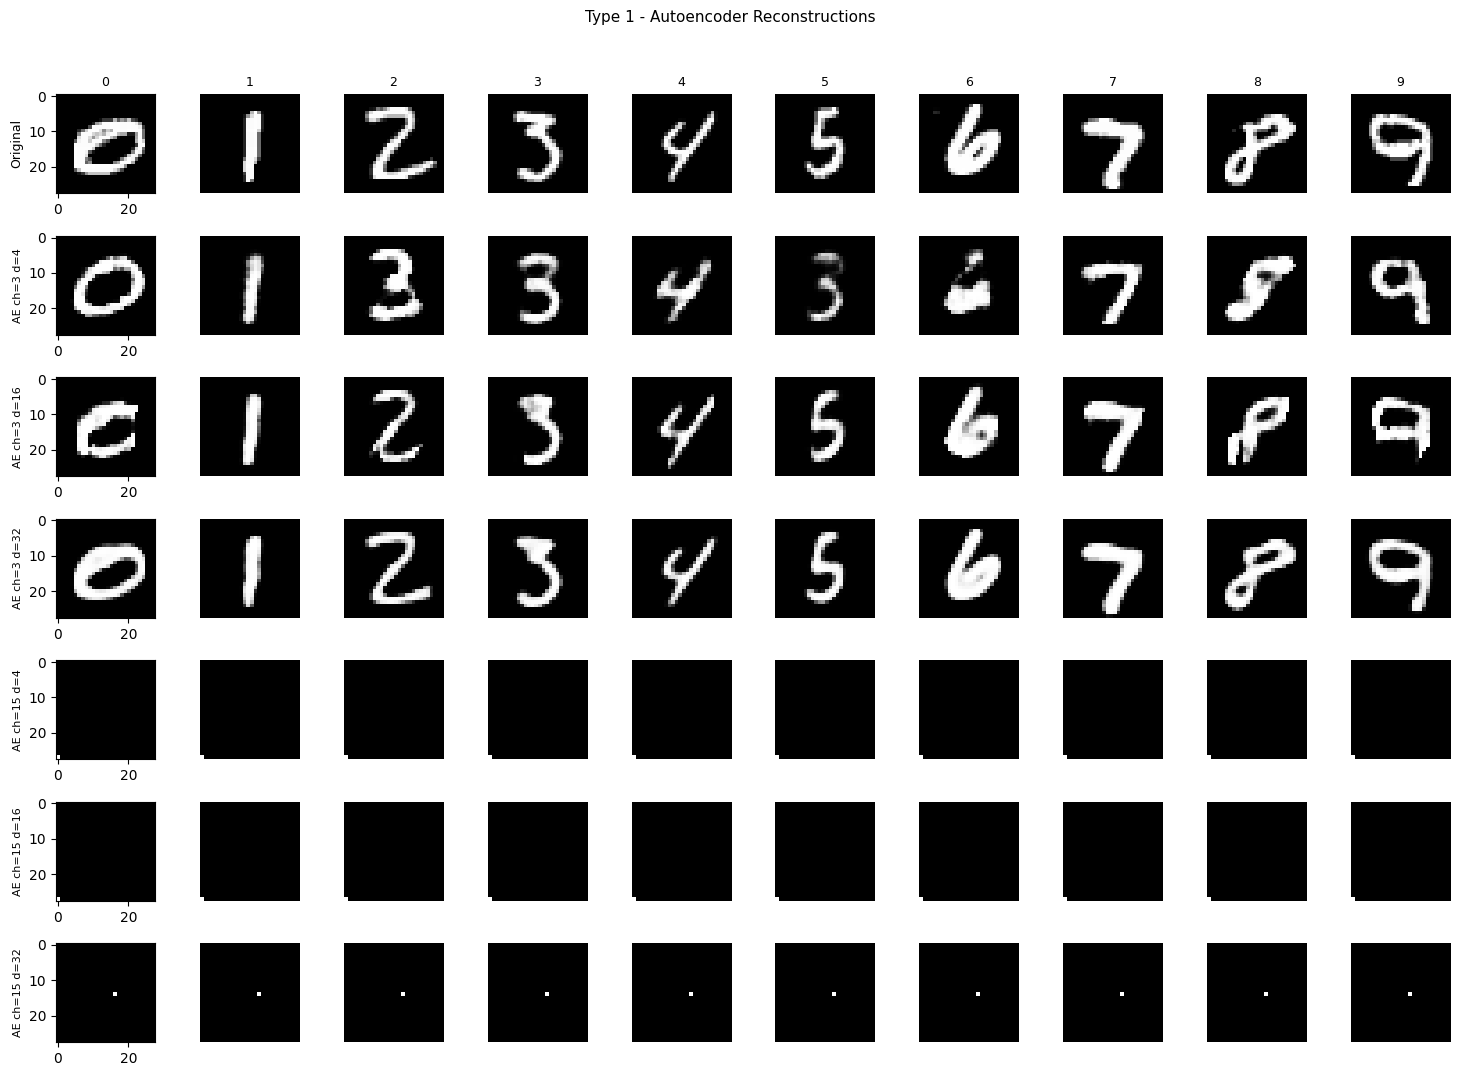

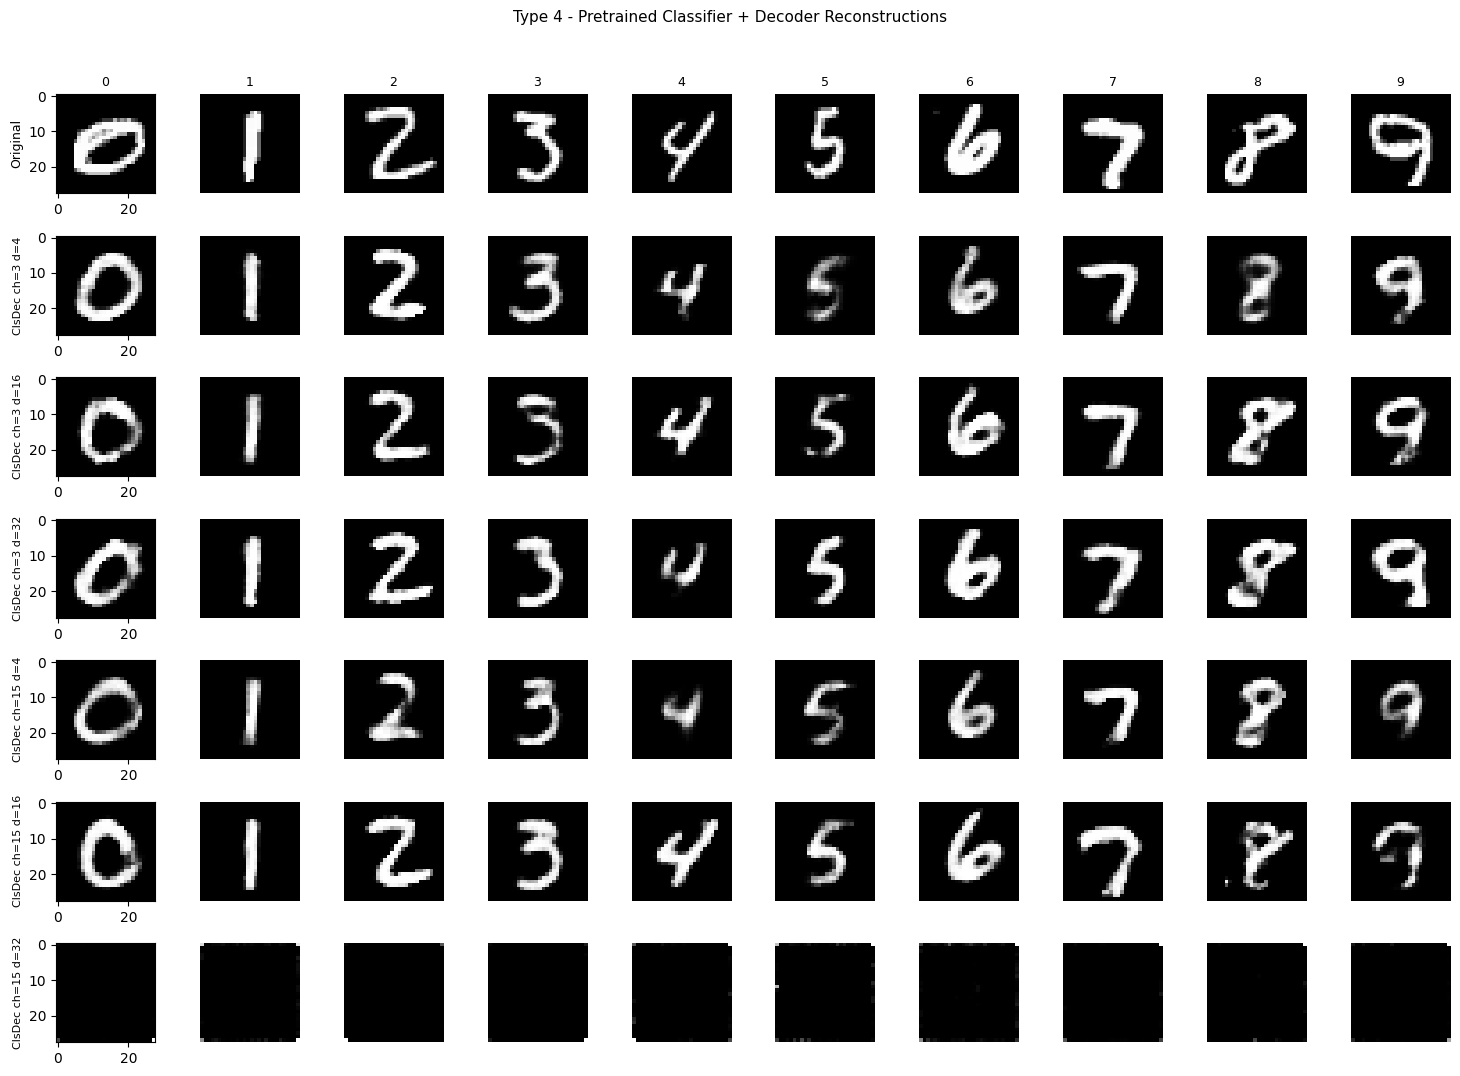

In [9]:
import matplotlib.pyplot as plt

def get_one_per_digit(loader):
    found = {}
    for images, labels in loader:
        for img, label in zip(images, labels):
            d = label.item()
            if d not in found:
                found[d] = img
            if len(found) == 10:
                break
        if len(found) == 10:
            break
    return torch.stack([found[d] for d in range(10)])  # ordered 0-9

def show_reconstructions(models_dict, images, title="Original vs. Reconstructed"):
    n = images.shape[0]
    rows = 1 + len(models_dict)
    fig, axes = plt.subplots(rows, n, figsize=(n * 1.5, rows * 1.5))
    fig.suptitle(title, fontsize=11, y=1.02)

    for i in range(n):
        axes[0, i].imshow(images[i].squeeze(), cmap="gray")
        axes[0, i].axis("off")
        axes[0, i].set_title(str(i), fontsize=9)
    axes[0, 0].set_ylabel("Original", fontsize=9)
    axes[0, 0].axis("on")

    for row, (label, model) in enumerate(models_dict.items(), start=1):
        device = next(model.parameters()).device
        model.eval()
        with torch.no_grad():
            reconstructed = model(images.to(device)).cpu()
        for i in range(n):
            axes[row, i].imshow(reconstructed[i].squeeze(), cmap="gray")
            axes[row, i].axis("off")
        axes[row, 0].set_ylabel(label, fontsize=8)
        axes[row, 0].axis("on")

    plt.tight_layout()
    plt.show()

train_loader_vis = get_mnist(batch_size=256, train=True)
sample_train_images = get_one_per_digit(train_loader_vis)

show_reconstructions(
    {f"AE ch={m.kwargs['hidden_channels']} d={m.kwargs['latent_dim']}": m for m in trained_ae_models},
    sample_train_images,
    title="Type 1 - Autoencoder Reconstructions",
)
show_reconstructions(
    {f"ClsDec ch={m.kwargs['hidden_channels']} d={m.kwargs['latent_dim']}": m for m in trained_cls_dec_models},
    sample_train_images,
    title="Type 4 - Pretrained Classifier + Decoder Reconstructions",
)
